# 성남시 Parquet 데이터 구조 탐색기

**목적:** `02_통합데이터/parquet/` 폴더의 모든 Parquet 파일 구조를 한눈에 확인  
**생성일:** 2026-04-08  

| 파일 | 레이어 | 행 수 | 크기 |
|------|--------|-------|------|
| raw_sales_day | Layer 0 (신규) | 87,265,541 | 557.5 MB |
| raw_credit_inout | Layer 0 (신규) | 256,300 | 3.7 MB |
| raw_telecom_t4 | Layer 0 (신규) | 1,211,106 | 8.6 MB |
| merge_card_merchant | Layer 0 | 2,130,071 | 15.7 MB |
| merge_credit_info | Layer 0 | 18,586 | 1.6 MB |
| merge_corp | Layer 0 | 275,467 | 0.5 MB |
| merge_card_sales_monthly | Layer 0* | 972 | <0.1 MB |
| merge_credit_inout | Layer 0* | 216 | <0.1 MB |
| merge_telecom_t4_monthly | Layer 0* | 105 | <0.1 MB |
| master_district_monthly | Layer 1 | 108 | 0.1 MB |

> ⚠️ `raw_sales_day`는 8700만 행 — 전체 로딩 시 메모리 부족 가능. 해당 섹션에서 10,000행 샘플로만 조회합니다.

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import os
import platform
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# Parquet 경로 — 노트북 위치 기준 자동 탐색
try:
    _nb_dir = os.path.dirname(os.path.abspath('parquet_explorer.ipynb'))
except:
    _nb_dir = os.getcwd()
PQ_DIR = os.path.normpath(os.path.join(_nb_dir, '..', '02_통합데이터', 'parquet'))
if not os.path.isdir(PQ_DIR):
    PQ_DIR = '/sessions/wizardly-fervent-gauss/mnt/성남시/02_통합데이터/parquet'

print('Parquet 디렉토리:', PQ_DIR)
files = [f for f in sorted(os.listdir(PQ_DIR)) if f.endswith('.parquet') and 'new' not in f]
print('파일 수:', len(files))
for f in files:
    print(' -', f)


Parquet 디렉토리: /sessions/wizardly-fervent-gauss/mnt/성남시/02_통합데이터/parquet
파일 수: 10
 - master_district_monthly.parquet
 - merge_card_merchant.parquet
 - merge_card_sales_monthly.parquet
 - merge_corp.parquet
 - merge_credit_info.parquet
 - merge_credit_inout.parquet
 - merge_telecom_t4_monthly.parquet
 - raw_credit_inout.parquet
 - raw_sales_day.parquet
 - raw_telecom_t4.parquet


In [2]:
LAYER_MAP = {
    'raw_sales_day': 'Layer 0 (신규)',
    'raw_credit_inout': 'Layer 0 (신규)',
    'raw_telecom_t4': 'Layer 0 (신규)',
    'merge_card_merchant': 'Layer 0',
    'merge_credit_info': 'Layer 0',
    'merge_corp': 'Layer 0',
    'merge_card_sales_monthly': 'Layer 0*',
    'merge_credit_inout': 'Layer 0*',
    'merge_telecom_t4_monthly': 'Layer 0*',
    'master_district_monthly': 'Layer 1',
}

summary = []
for f in files:
    path = os.path.join(PQ_DIR, f)
    meta = pq.read_metadata(path)
    size_mb = os.path.getsize(path) / 1024**2
    name = f.replace('.parquet', '')
    summary.append({
        '파일명': name,
        '레이어': LAYER_MAP.get(name, '?'),
        '행 수': f'{meta.num_rows:,}',
        '열 수': meta.num_columns,
        '크기(MB)': round(size_mb, 2),
        'Row Groups': meta.num_row_groups,
    })

print('=== Parquet 파일 전체 요약 ===')
display(pd.DataFrame(summary))


=== Parquet 파일 전체 요약 ===


,파일명,레이어,행 수,열 수,크기(MB),Row Groups
0,master_district_monthly,Layer 1,108,50,0.06,1
1,merge_card_merchant,Layer 0,"2,130,071",22,15.65,3
2,merge_card_sales_monthly,Layer 0*,972,6,0.02,1
3,merge_corp,Layer 0,"275,467",16,0.49,1
4,merge_credit_info,Layer 0,"18,586",41,1.64,1
5,merge_credit_inout,Layer 0*,216,10,0.01,1
6,merge_telecom_t4_monthly,Layer 0*,105,4,0.00,1
7,raw_credit_inout,Layer 0 (신규),"256,300",44,3.75,1
8,raw_sales_day,Layer 0 (신규),"87,265,541",14,557.49,108
9,raw_telecom_t4,Layer 0 (신규),"1,211,106",13,8.59,2


---
## 공통 헬퍼 함수

In [3]:
def inspect_parquet(filename, nrows=5, large=False):
    """Parquet 파일 구조 요약 함수"""
    path = os.path.join(PQ_DIR, filename)
    meta = pq.read_metadata(path)
    sep = '=' * 60
    print(sep)
    print('  파일:', filename)
    print('  행 수: {:,}  |  열 수: {}  |  크기: {:.2f} MB'.format(
        meta.num_rows, meta.num_columns, os.path.getsize(path)/1024**2))
    print('  Row Groups:', meta.num_row_groups)
    print(sep)

    # 데이터 로딩
    if large:
        pf = pq.ParquetFile(path)
        df = next(pf.iter_batches(batch_size=10000)).to_pandas()
        print('  [대용량 파일 - 첫 10,000행 샘플]')
    else:
        df = pd.read_parquet(path)

    # 1. 컬럼 구조
    print('[1] 컬럼 구조')
    schema_df = pd.DataFrame({
        '컬럼명': df.columns,
        '타입': df.dtypes.values,
        '결측 수': df.isnull().sum().values,
        '결측률(%)': (df.isnull().sum().values / len(df) * 100).round(1),
        '유니크 수': df.nunique().values,
    })
    display(schema_df)

    # 2. 상위 N행
    print('[2] 상위 {}행'.format(nrows))
    display(df.head(nrows))

    # 3. 수치형 기초 통계
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print('[3] 수치형 기초 통계')
        display(df[num_cols].describe().round(2).T)

    return df


---
## 1. master_district_monthly
> Layer 1 | 108행 × 50열 — 구×월 집계 파일. 소스 간 교차 분석 전용. **생태학적 오류 주의**

In [4]:
df_master = inspect_parquet('master_district_monthly.parquet')

  파일: master_district_monthly.parquet
  행 수: 108  |  열 수: 50  |  크기: 0.06 MB
  Row Groups: 1
[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ym,int64,0,0.0,36
1,cty_rgn_no,int64,0,0.0,3
2,gu_nm,object,0,0.0,3
3,mer_total,int64,0,0.0,108
4,mer_open,int64,0,0.0,93
5,mer_stop,int64,0,0.0,107
6,mer_close,int64,0,0.0,91
7,mer_fran,int64,0,0.0,102
8,mer_op_lt1y,int64,0,0.0,108
9,mer_op_1_2y,int64,0,0.0,105


[2] 상위 5행


,ym,cty_rgn_no,gu_nm,mer_total,mer_open,mer_stop,mer_close,mer_fran,mer_op_lt1y,mer_op_1_2y,...,new_hous_rate,mer_active,stop_rate_pct,fran_rate_pct,mer_indep,non_econ_cnt,non_econ_rate,tot_net,yes_income_in,income_in_rate
0,202301,41131,수정구,22583,260,9101,342,1329,3599,3069,...,0.000679,13482,40.30,5.88,21254,19007,9.41,-3025.0,5276,33.83
1,202301,41133,중원구,23023,203,10573,318,1018,3033,2316,...,0.001384,12450,45.92,4.42,22005,13282,7.79,-3341.0,4039,35.96
2,202301,41135,분당구,53305,573,24945,610,4178,7316,6188,...,0.000869,28360,46.80,7.84,49127,24826,6.48,-4538.0,11782,44.58
3,202302,41131,수정구,22472,309,9273,234,1340,3391,3089,...,0.000561,13199,41.26,5.96,21132,19173,9.52,-3640.0,4934,34.00
4,202302,41133,중원구,22885,289,10688,277,1034,2881,2361,...,0.000481,12197,46.70,4.52,21851,13207,7.85,-3955.0,3704,35.42


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ym,108.0,2.024065e+05,8.210000e+01,2.023010e+05,2.023098e+05,2.024065e+05,2.025032e+05,2.025120e+05
cty_rgn_no,108.0,4.113300e+04,1.640000e+00,4.113100e+04,4.113100e+04,4.113300e+04,4.113500e+04,4.113500e+04
mer_total,108.0,3.506384e+04,1.606391e+04,2.228000e+04,2.314775e+04,2.470850e+04,5.465450e+04,6.411200e+04
mer_open,108.0,4.593100e+02,2.200900e+02,2.030000e+02,2.982500e+02,3.555000e+02,6.257500e+02,1.042000e+03
mer_stop,108.0,1.668431e+04,8.418130e+03,9.101000e+03,1.057175e+04,1.163900e+04,2.620975e+04,3.343300e+04
mer_close,108.0,3.689300e+02,1.684200e+02,1.910000e+02,2.557500e+02,2.965000e+02,4.895000e+02,1.363000e+03
mer_fran,108.0,2.481440e+03,1.725840e+03,1.018000e+03,1.181000e+03,1.419500e+03,4.539750e+03,5.254000e+03
mer_op_lt1y,108.0,4.514580e+03,1.815600e+03,2.610000e+03,3.048750e+03,3.555000e+03,6.644250e+03,8.268000e+03
mer_op_1_2y,108.0,4.024750e+03,1.728460e+03,2.068000e+03,2.800500e+03,3.067000e+03,6.067250e+03,7.188000e+03
mer_op_2_3y,108.0,3.415480e+03,1.424120e+03,1.903000e+03,2.285250e+03,2.652500e+03,5.291500e+03,5.911000e+03


In [5]:
# 구별 × 연도별 폐업률 피벗
df_master['year'] = df_master['ym'] // 100
pivot = df_master.groupby(['year','gu_nm'])['close_rate'].mean().unstack().round(2)
print('[폐업률(%) 연도별 구 평균]')
display(pivot)


[폐업률(%) 연도별 구 평균]


gu_nm,분당구,수정구,중원구
year,,,
2023,0.81,0.94,1.01
2024,0.76,0.82,0.85
2025,0.75,0.90,0.86


---
## 2. merge_card_merchant
> Layer 0 | 2,130,071행 × 22열 — 업종×행정동×블록×월. 업종별·행정동별 EDA, ML의 핵심 파일

In [6]:
df_merchant = inspect_parquet('merge_card_merchant.parquet')

  파일: merge_card_merchant.parquet
  행 수: 2,130,071  |  열 수: 22  |  크기: 15.65 MB
  Row Groups: 3


[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ta_ym,int64,0,0.0,36
1,cty_rgn_no,int64,0,0.0,3
2,admi_cty_no,int64,0,0.0,50
3,blk_cd,int64,0,0.0,5442
4,card_tpbuz_cd,object,0,0.0,83
5,card_tpbuz_nm_1,object,0,0.0,9
6,card_tpbuz_nm_2,object,0,0.0,83
7,sale,object,387860,18.2,5
8,mm_cnt,int64,0,0.0,4574
9,mer_cnt,int64,0,0.0,297


[2] 상위 5행


,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,...,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt,gu_nm,ym
0,202301,41135,41135510,100470,Q13,음식,커피/음료,A,57,1,...,1,0,0,0,0,0,1,0,분당구,202301
1,202301,41135,41135510,100470,R07,학문/교육,입시학원,A,84,1,...,1,0,0,0,0,0,0,1,분당구,202301
2,202301,41135,41135680,101678,O03,여가/오락,일반스포츠,A,1,1,...,0,1,0,0,1,0,0,0,분당구,202301
3,202301,41135,41135680,101678,O03,여가/오락,일반스포츠,None,32,1,...,0,1,0,0,1,0,0,0,분당구,202301
4,202301,41135,41135680,101678,O03,여가/오락,일반스포츠,신규,0,1,...,1,0,1,0,0,0,0,0,분당구,202301


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ta_ym,2130071.0,202407.17,82.14,202301.0,202309.0,202407.0,202504.0,202512.0
cty_rgn_no,2130071.0,41133.50,1.66,41131.0,41133.0,41133.0,41135.0,41135.0
admi_cty_no,2130071.0,41134092.25,1671.83,41131510.0,41133510.0,41133670.0,41135620.0,41135680.0
blk_cd,2130071.0,264837.81,169426.41,133.0,129658.0,147483.0,425011.0,574592.0
mm_cnt,2130071.0,159.71,490.61,0.0,38.0,99.0,197.0,134368.0
mer_cnt,2130071.0,1.78,6.33,0.0,1.0,1.0,2.0,1207.0
fran_cnt,2130071.0,0.13,3.21,0.0,0.0,0.0,0.0,633.0
open_cnt,2130071.0,0.02,0.21,0.0,0.0,0.0,0.0,58.0
stop_cnt,2130071.0,0.85,4.15,0.0,0.0,1.0,1.0,917.0
close_cnt,2130071.0,0.02,0.15,0.0,0.0,0.0,0.0,44.0


In [7]:
print('[업종 대분류 분포]')
display(df_merchant['card_tpbuz_nm_1'].value_counts().reset_index().rename(columns={'count':'행 수'}))
print()
print('[구별 행 수]')
display(df_merchant['gu_nm'].value_counts())


[업종 대분류 분포]


,card_tpbuz_nm_1,행 수
0,소매/유통,662539
1,음식,636418
2,생활서비스,319161
3,학문/교육,185292
4,의료/건강,141450
5,여가/오락,97602
6,공공/기업/단체,69436
7,미디어/통신,13274
8,공연/전시,4899



[구별 행 수]


gu_nm
분당구    1064991
중원구     534650
수정구     530430
Name: count, dtype: int64

---
## 3. merge_credit_info
> Layer 0 | 18,586행 × 41열 — 성별×연령×구×월. 신용·금융 지표 분석 핵심 파일

In [8]:
df_credit = inspect_parquet('merge_credit_info.parquet')

  파일: merge_credit_info.parquet
  행 수: 18,586  |  열 수: 41  |  크기: 1.64 MB
  Row Groups: 1
[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,BS_YR_MON,int64,0,0.0,36
1,SIGUNGU,int64,0,0.0,3
2,BCD,int64,0,0.0,44
3,GENDER,int64,0,0.0,2
4,AGE,int64,0,0.0,6
5,TOT_CNT,int64,0,0.0,4427
6,SUM_LOAN,int64,0,0.0,15779
7,SUM_CRED_LOAN,int64,0,0.0,11596
8,SUM_COL_LOAN,int64,0,0.0,15278
9,SUM_ETC_LOAN,int64,0,0.0,6105


[2] 상위 5행


,BS_YR_MON,SIGUNGU,BCD,GENDER,AGE,TOT_CNT,SUM_LOAN,SUM_CRED_LOAN,SUM_COL_LOAN,SUM_ETC_LOAN,...,ABRO_CARD_CNT,ECON_CNT,NECON_CNT,MULTI_HOUS_CNT,MANY_HOUS_CNT,NEW_HOUS_CNT,SUM_NEW_HOUS_LOAN,STAY_2YRS_CNT,ym,gu_nm
0,202301,41131,4113110100,1,20,2984,3621500,820000,2288700,515100,...,227,2874,66,1177,5,0,0,1325,202301,수정구
1,202301,41131,4113110100,1,30,3523,28442200,5343300,22264500,929000,...,476,3375,105,1527,24,8,241500,1436,202301,수정구
2,202301,41131,4113110100,1,40,3467,27136800,5732700,20653100,871600,...,314,3266,156,1449,54,4,115100,1641,202301,수정구
3,202301,41131,4113110100,1,50,4071,22696800,5512900,16334200,907300,...,129,3656,318,1416,108,4,73700,2156,202301,수정구
4,202301,41131,4113110100,1,60,3526,11676700,1904300,9378100,405000,...,60,3038,369,1265,103,3,38900,1966,202301,수정구


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
BS_YR_MON,18586.0,2.024065e+05,81.69,2.023010e+05,2.023100e+05,2.024070e+05,2.025030e+05,2.025120e+05
SIGUNGU,18586.0,4.113309e+04,1.78,4.113100e+04,4.113100e+04,4.113300e+04,4.113500e+04,4.113500e+04
BCD,18586.0,4.113320e+09,177667.96,4.113110e+09,4.113111e+09,4.113311e+09,4.113511e+09,4.113512e+09
GENDER,18586.0,1.500000e+00,0.50,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
AGE,18586.0,4.499000e+01,17.08,2.000000e+01,3.000000e+01,4.000000e+01,6.000000e+01,7.000000e+01
TOT_CNT,18586.0,1.503250e+03,1473.33,0.000000e+00,1.200000e+02,1.171000e+03,2.422000e+03,7.522000e+03
SUM_LOAN,18586.0,8.117443e+06,12389559.54,0.000000e+00,6.485250e+05,3.199300e+06,1.014918e+07,1.013573e+08
SUM_CRED_LOAN,18586.0,1.722273e+06,3074683.68,0.000000e+00,9.920000e+04,4.728000e+05,2.013075e+06,2.814910e+07
SUM_COL_LOAN,18586.0,6.198893e+06,9303357.73,0.000000e+00,5.038750e+05,2.471250e+06,7.927125e+06,7.605220e+07
SUM_ETC_LOAN,18586.0,2.157675e+05,281132.22,0.000000e+00,1.450000e+04,1.057000e+05,3.268750e+05,4.307100e+06


In [9]:
print('[연령대 × 구 행 수 분포]')
display(pd.crosstab(df_credit['AGE'], df_credit['gu_nm']))


[연령대 × 구 행 수 분포]


gu_nm,분당구,수정구,중원구
AGE,,,
20,1292,1167,648
30,1292,1152,648
40,1296,1155,648
50,1296,1152,648
60,1296,1152,648
70,1296,1152,648


---
## 4. merge_corp
> Layer 0 | 275,467행 × 16열 — 업종×행정동×월. 기업(법인+신규) 데이터

In [10]:
df_corp = inspect_parquet('merge_corp.parquet')

  파일: merge_corp.parquet
  행 수: 275,467  |  열 수: 16  |  크기: 0.49 MB
  Row Groups: 1


[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,stdr_ym,int64,0,0.0,36
1,sido_nm,object,0,0.0,1
2,sigun_nm,object,0,0.0,3
3,admi_nm,object,0,0.0,50
4,induty_pri_cd,object,0,0.0,40
5,induty_pri_nm,object,0,0.0,40
6,induty_med_cd,object,0,0.0,144
7,induty_med_nm,object,0,0.0,75
8,vpap_comp_cn,int64,0,0.0,5
9,kosdaq_comp_cn,int64,0,0.0,17


[2] 상위 5행


,stdr_ym,sido_nm,sigun_nm,admi_nm,induty_pri_cd,induty_pri_nm,induty_med_cd,induty_med_nm,vpap_comp_cn,kosdaq_comp_cn,konex_comp_cn,oc_comp_cn,co_ctx_comp_cn,ym,cty_rgn_no,ncr_crp_comp_cn
0,202301,경기,성남시 분당구,구미1동,10A0000000,"A 농업, 임업 및 어업(01~03)",10A0100000,농업,0,0,0,0,2,202301,41135,0
1,202301,경기,성남시 분당구,구미1동,10A0000000,"A 농업, 임업 및 어업(01~03)",10A0200000,임업,0,0,0,0,5,202301,41135,0
2,202301,경기,성남시 분당구,구미1동,10B0000000,B 광업(05~08),10B0700000,비금속광물 광업; 연료용 제외,0,0,0,0,1,202301,41135,0
3,202301,경기,성남시 분당구,구미1동,10C0000000,C 제조업(10~34),10C1000000,식료품 제조업,0,0,0,1,4,202301,41135,1
4,202301,경기,성남시 분당구,구미1동,10C0000000,C 제조업(10~34),10C1000000,식료품 제조업,0,0,0,1,4,202301,41135,1


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
stdr_ym,275467.0,202407.70,81.07,202301.0,202310.0,202407.0,202504.0,202512.0
vpap_comp_cn,275467.0,0.03,0.18,0.0,0.0,0.0,0.0,4.0
kosdaq_comp_cn,275467.0,0.13,0.90,0.0,0.0,0.0,0.0,19.0
konex_comp_cn,275467.0,0.01,0.08,0.0,0.0,0.0,0.0,1.0
oc_comp_cn,275467.0,0.88,4.23,0.0,0.0,0.0,0.0,91.0
co_ctx_comp_cn,275467.0,20.19,58.41,0.0,2.0,5.0,13.0,784.0
ym,275467.0,202407.70,81.07,202301.0,202310.0,202407.0,202504.0,202512.0
cty_rgn_no,275467.0,41134.10,1.53,41131.0,41133.0,41135.0,41135.0,41135.0
ncr_crp_comp_cn,275467.0,1.18,0.87,0.0,1.0,1.0,1.0,12.0


---
## 5. merge_card_sales_monthly
> Layer 0* | 972행 × 6열 — 업종대분류×구×월 집계. 일자·시간대·성별·연령 정보 손실

In [11]:
df_sales_m = inspect_parquet('merge_card_sales_monthly.parquet')

  파일: merge_card_sales_monthly.parquet
  행 수: 972  |  열 수: 6  |  크기: 0.02 MB
  Row Groups: 1
[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ym,int64,0,0.0,36
1,cty_rgn_no,int64,0,0.0,3
2,card_tpbuz_nm_1,object,0,0.0,9
3,amt_sum,int64,0,0.0,972
4,cnt_sum,int64,0,0.0,972
5,gu_nm,object,0,0.0,3


[2] 상위 5행


,ym,cty_rgn_no,card_tpbuz_nm_1,amt_sum,cnt_sum,gu_nm
0,202301,41131,공공/기업/단체,903882186,22890,수정구
1,202301,41131,공연/전시,112077272,5392,수정구
2,202301,41131,미디어/통신,1391610933,98006,수정구
3,202301,41131,생활서비스,12386348033,263629,수정구
4,202301,41131,소매/유통,64732264289,3092720,수정구


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ym,972.0,2.024065e+05,8.176000e+01,202301.0,2.023098e+05,2.024065e+05,2.025032e+05,2.025120e+05
cty_rgn_no,972.0,4.113300e+04,1.630000e+00,41131.0,4.113100e+04,4.113300e+04,4.113500e+04,4.113500e+04
amt_sum,972.0,3.019800e+11,8.861199e+11,13376460.0,3.483694e+09,1.765338e+10,7.073896e+10,5.557821e+12
cnt_sum,972.0,6.293012e+06,1.759209e+07,888.0,6.337100e+04,3.589315e+05,2.111476e+06,9.969145e+07


---
## 6. merge_credit_inout
> Layer 0* | 216행 × 10열 — 방향(IN/OUT)×구×월 집계. 출발지/목적지 정보 손실  
> ⚠️ out_* 계열: 2025년 12개월 결측

In [12]:
df_inout = inspect_parquet('merge_credit_inout.parquet')

  파일: merge_credit_inout.parquet
  행 수: 216  |  열 수: 10  |  크기: 0.01 MB
  Row Groups: 1
[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ym,int64,0,0.0,48
1,BS_SIGNGU,int64,0,0.0,3
2,TOT_CNT,int64,0,0.0,153
3,SELF_ENT,int64,0,0.0,200
4,YES_INCOME,int64,0,0.0,211
5,AVG_INC,float64,0,0.0,208
6,AVG_CARD,float64,0,0.0,216
7,AVG_LOAN,float64,0,0.0,216
8,direction,object,0,0.0,2
9,gu_nm,object,0,0.0,3


[2] 상위 5행


,ym,BS_SIGNGU,TOT_CNT,SELF_ENT,YES_INCOME,AVG_INC,AVG_CARD,AVG_LOAN,direction,gu_nm
0,202301,41131,15594,1894,5276,1054.404145,689.982729,31420.552677,IN,수정구
1,202301,41133,11231,1257,4039,1056.953642,725.827815,30676.821192,IN,중원구
2,202301,41135,26431,3386,11782,2355.541320,1594.490711,86901.345291,IN,분당구
3,202302,41131,14510,1770,4934,1038.062284,657.439446,28894.463668,IN,수정구
4,202302,41133,10457,1212,3704,998.684211,644.736842,26992.105263,IN,중원구


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ym,216.0,202356.50,96.03,202201.00,202303.75,202356.50,202409.25,202512.00
BS_SIGNGU,216.0,41133.00,1.64,41131.00,41131.00,41133.00,41135.00,41135.00
TOT_CNT,216.0,20475.89,6633.85,10457.00,15068.50,17897.00,25699.75,34590.00
SELF_ENT,216.0,2520.10,894.94,1212.00,1802.25,2191.50,3422.25,4365.00
YES_INCOME,216.0,8174.03,3371.13,3684.00,5584.75,6504.50,11294.75,14613.00
AVG_INC,216.0,1742.65,565.31,998.68,1331.52,1489.76,2358.60,2757.03
AVG_CARD,216.0,1136.42,357.18,572.93,871.21,964.21,1560.24,1805.02
AVG_LOAN,216.0,54007.92,20035.56,26956.64,38318.89,44362.02,74772.43,96102.70


In [13]:
print('[direction 분포]')
display(df_inout['direction'].value_counts())
miss = df_inout.isnull().sum()
miss = miss[miss > 0]
if len(miss):
    print('[결측값]')
    display(miss)


[direction 분포]


direction
IN     108
OUT    108
Name: count, dtype: int64

---
## 7. merge_telecom_t4_monthly
> Layer 0* | 105행 × 4열 — 구×월 집계. 요일·시간대·목적·성별·연령 전부 손실

In [14]:
df_telecom_m = inspect_parquet('merge_telecom_t4_monthly.parquet')

  파일: merge_telecom_t4_monthly.parquet
  행 수: 105  |  열 수: 4  |  크기: 0.00 MB
  Row Groups: 1
[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ym,float64,0,0.0,35
1,cty_rgn_no,float64,0,0.0,3
2,gu_nm,object,0,0.0,3
3,total_inflow,float64,0,0.0,105


[2] 상위 5행


,ym,cty_rgn_no,gu_nm,total_inflow
0,202301.0,41131.0,성남시 수정구,8126042.30
1,202301.0,41133.0,성남시 중원구,7441546.50
2,202301.0,41135.0,성남시 분당구,23788904.11
3,202302.0,41131.0,성남시 수정구,7859456.86
4,202302.0,41133.0,성남시 중원구,7176631.77


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ym,105.0,202403.74,81.60,202301.00,202309.0,202406.00,202504.00,202512.0
cty_rgn_no,105.0,41133.00,1.64,41131.00,41131.0,41133.00,41135.00,41135.0
total_inflow,105.0,14446294.00,8333323.77,7138961.32,8126042.3,9433348.85,24916300.34,34468227.5


---
## 8. raw_credit_inout
> Layer 0 신규 | 256,300행 × 44열 — 전입/전출 원본 세로 병합. 출발지/목적지 시도·시군구 정보 보존

In [15]:
df_raw_inout = inspect_parquet('raw_credit_inout.parquet')

  파일: raw_credit_inout.parquet
  행 수: 256,300  |  열 수: 44  |  크기: 3.75 MB
  Row Groups: 1


[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,prev_ym,float64,132794,51.8,35
1,origin_sido,float64,129319,50.5,3
2,origin_signgu,float64,129319,50.5,80
3,ym,float64,3630,1.4,48
4,BS_SIGNGU,int64,0,0.0,3
5,BS_HCD,int64,0,0.0,51
6,TOT_CNT,int64,0,0.0,631
7,M_CNT,int64,0,0.0,382
8,FM_CNT,int64,0,0.0,383
9,YES_INCOME,int64,0,0.0,364


[2] 상위 5행


,prev_ym,origin_sido,origin_signgu,ym,BS_SIGNGU,BS_HCD,TOT_CNT,M_CNT,FM_CNT,YES_INCOME,...,CNT_6,CNT_7,CNT_8,CNT_9,CNT_10,direction,gu_nm,dest_ym,dest_sido,dest_signgu
0,202201.0,11.0,11110.0,202301.0,41131,4113151000,0,0,0,0,...,0,0,0,0,0,IN,수정구,NaN,NaN,NaN
1,202201.0,11.0,11140.0,202301.0,41131,4113151000,0,0,0,0,...,0,0,0,0,0,IN,수정구,NaN,NaN,NaN
2,202201.0,11.0,11170.0,202301.0,41131,4113151000,0,0,0,0,...,0,0,0,0,0,IN,수정구,NaN,NaN,NaN
3,202201.0,11.0,11200.0,202301.0,41131,4113151000,0,0,0,0,...,0,0,0,0,0,IN,수정구,NaN,NaN,NaN
4,202201.0,11.0,11215.0,202301.0,41131,4113151000,11,8,3,4,...,0,0,0,0,0,IN,수정구,NaN,NaN,NaN


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
prev_ym,123506.0,2.023077e+05,83.01,2.022010e+05,2.022090e+05,2.023070e+05,2.024040e+05,2.024120e+05
origin_sido,126981.0,2.925000e+01,13.83,1.100000e+01,1.100000e+01,4.100000e+01,4.100000e+01,4.100000e+01
origin_signgu,126981.0,2.962570e+04,13809.30,1.111000e+04,1.156000e+04,4.111700e+04,4.137000e+04,4.183000e+04
ym,252670.0,2.023579e+05,96.25,2.022010e+05,2.023030e+05,2.024010e+05,2.024100e+05,2.025120e+05
BS_SIGNGU,256300.0,4.113321e+04,1.75,4.113100e+04,4.113100e+04,4.113300e+04,4.113500e+04,4.113500e+04
BS_HCD,256300.0,4.113380e+09,176482.51,4.113151e+09,4.113162e+09,4.113359e+09,4.113559e+09,4.113568e+09
TOT_CNT,256300.0,1.726000e+01,51.29,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,1.716000e+03
M_CNT,256300.0,8.890000e+00,25.84,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,8.590000e+02
FM_CNT,256300.0,8.360000e+00,25.66,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00,8.570000e+02
YES_INCOME,256300.0,6.890000e+00,19.43,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,6.430000e+02


In [16]:
print('[direction 분포]')
display(df_raw_inout['direction'].value_counts())
origin_cols = [c for c in df_raw_inout.columns if any(k in c.lower() for k in ['origin','dest','sido'])]
if origin_cols:
    print('[출발지/목적지 컬럼:', origin_cols, ']')
    display(df_raw_inout[origin_cols].head(10))


[direction 분포]


direction
OUT    129319
IN     126981
Name: count, dtype: int64

[출발지/목적지 컬럼: ['origin_sido', 'origin_signgu', 'dest_ym', 'dest_sido', 'dest_signgu'] ]


,origin_sido,origin_signgu,dest_ym,dest_sido,dest_signgu
0,11.0,11110.0,NaN,NaN,NaN
1,11.0,11140.0,NaN,NaN,NaN
2,11.0,11170.0,NaN,NaN,NaN
3,11.0,11200.0,NaN,NaN,NaN
4,11.0,11215.0,NaN,NaN,NaN
5,11.0,11230.0,NaN,NaN,NaN
6,11.0,11260.0,NaN,NaN,NaN
7,11.0,11290.0,NaN,NaN,NaN
8,11.0,11305.0,NaN,NaN,NaN
9,11.0,11320.0,NaN,NaN,NaN


---
## 9. raw_telecom_t4
> Layer 0 신규 | 1,211,106행 × 13열 — 통신 T4 원본 세로 병합. 요일·시간대·목적·성별·연령 보존

In [17]:
df_raw_telecom = inspect_parquet('raw_telecom_t4.parquet')

  파일: raw_telecom_t4.parquet
  행 수: 1,211,106  |  열 수: 13  |  크기: 8.59 MB
  Row Groups: 2


[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ym,int64,0,0.0,36
1,DOW,object,0,0.0,7
2,D_TIME_CD,int64,0,0.0,24
3,cty_rgn_no,int64,0,0.0,3
4,mega_nm,object,0,0.0,1
5,gu_nm_raw,object,0,0.0,3
6,center_x,int64,0,0.0,3
7,center_y,int64,0,0.0,3
8,PURPOSE,int64,0,0.0,6
9,SEX_CD,object,0,0.0,3


[2] 상위 5행


,ym,DOW,D_TIME_CD,cty_rgn_no,mega_nm,gu_nm_raw,center_x,center_y,PURPOSE,SEX_CD,AGE_GRP,CNT,gu_nm
0,202301,수,1,41133,경기도,성남시 중원구,970268,1937199,1,W,4,3.06,중원구
1,202301,월,10,41133,경기도,성남시 중원구,970268,1937199,2,M,4,24.44,중원구
2,202301,목,2,41135,경기도,성남시 분당구,965120,1931210,6,W,8,78.93,분당구
3,202301,월,8,41131,경기도,성남시 수정구,964981,1937423,6,M,3,1628.27,수정구
4,202301,목,11,41131,경기도,성남시 수정구,964981,1937423,6,M,6,4679.92,수정구


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ym,1211106.0,202407.22,81.72,202301.0,202310.00,202407.00,202504.0,202512.0
D_TIME_CD,1211106.0,12.00,6.56,0.0,7.00,12.00,18.0,23.0
cty_rgn_no,1211106.0,41133.26,1.67,41131.0,41131.00,41133.00,41135.0,41135.0
center_x,1211106.0,966560.14,2356.76,964981.0,964981.00,965120.00,970268.0,970268.0
center_y,1211106.0,1934745.98,3013.31,1931210.0,1931210.00,1937199.00,1937423.0,1937423.0
PURPOSE,1211106.0,2.58,2.50,0.0,0.00,1.00,6.0,6.0
AGE_GRP,1211106.0,5.29,2.65,1.0,3.00,5.00,8.0,12.0
CNT,1211106.0,1289.35,2752.08,1.0,37.29,230.83,1218.0,75761.0


In [18]:
for col in ['DOW','PURPOSE','SEX_CD','AGE_GRP']:
    if col in df_raw_telecom.columns:
        print('[{} 분포]'.format(col))
        display(df_raw_telecom[col].value_counts().sort_index())
        print()


[DOW 분포]


DOW
금    173588
목    173509
수    173387
월    172970
일    171611
토    172876
화    173165
Name: count, dtype: int64


[PURPOSE 분포]


PURPOSE
0    350322
1    270972
2    107323
3     60698
5     75197
6    346594
Name: count, dtype: int64


[SEX_CD 분포]


SEX_CD
F    324281
M    603868
W    282957
Name: count, dtype: int64


[AGE_GRP 분포]


AGE_GRP
1      73264
2     140602
3     160359
4     157685
5     125199
6     125469
7     124422
8     119708
9     110707
10     68831
11      4857
12         3
Name: count, dtype: int64

---
## 10. raw_sales_day (Layer 0 신규 | 87,265,541행 × 14열 | 557.5 MB)
> 매출 day 원본 36개월 세로 병합. **메모리 이슈로 10,000행 샘플만 로드**  
> 구분자 이력: 2301~2404 쉼표(`,`), 2405~2512 파이프(`|`)

In [19]:
df_raw_sales = inspect_parquet('raw_sales_day.parquet', large=True)


  파일: raw_sales_day.parquet
  행 수: 87,265,541  |  열 수: 14  |  크기: 557.49 MB
  Row Groups: 108
  [대용량 파일 - 첫 10,000행 샘플]
[1] 컬럼 구조


,컬럼명,타입,결측 수,결측률(%),유니크 수
0,ta_ymd,Int32,0,0.0,1
1,cty_rgn_no,Int32,0,0.0,1
2,admi_cty_no,Int32,0,0.0,11
3,card_tpbuz_cd,Int32,10000,100.0,0
4,card_tpbuz_nm_1,object,0,0.0,9
5,card_tpbuz_nm_2,object,0,0.0,61
6,hour,Int32,0,0.0,10
7,sex,object,0,0.0,2
8,age,int64,0,0.0,9
9,day,Int32,0,0.0,1


[2] 상위 5행


,ta_ymd,cty_rgn_no,admi_cty_no,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,hour,sex,age,day,amt,cnt,ym,gu_nm
0,20230101,41131,41131510,<NA>,소매/유통,가전제품,4,M,5,7,9251291,2,202301,수정구
1,20230101,41131,41131510,<NA>,소매/유통,가전제품,5,F,5,7,62392,4,202301,수정구
2,20230101,41131,41131510,<NA>,소매/유통,가전제품,5,F,6,7,153920,2,202301,수정구
3,20230101,41131,41131510,<NA>,소매/유통,가전제품,5,F,7,7,21515,2,202301,수정구
4,20230101,41131,41131510,<NA>,소매/유통,가전제품,5,M,6,7,544320,4,202301,수정구


[3] 수치형 기초 통계


,count,mean,std,min,25%,50%,75%,max
ta_ymd,10000.0,20230101.0,0.0,20230101.0,20230101.0,20230101.0,20230101.0,20230101.0
cty_rgn_no,10000.0,41131.0,0.0,41131.0,41131.0,41131.0,41131.0,41131.0
admi_cty_no,10000.0,41131549.61,25.85,41131510.0,41131530.0,41131550.0,41131570.0,41131600.0
card_tpbuz_cd,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
hour,10000.0,5.67,2.3,1.0,4.0,6.0,7.0,10.0
age,10000.0,5.18,1.62,2.0,4.0,5.0,6.0,10.0
day,10000.0,7.0,0.0,7.0,7.0,7.0,7.0,7.0
amt,10000.0,273796.85,1701087.21,18.0,25192.25,64341.0,172871.5,77272541.0
cnt,10000.0,9.45,22.0,2.0,2.0,3.0,7.0,410.0
ym,10000.0,202301.0,0.0,202301.0,202301.0,202301.0,202301.0,202301.0


In [20]:
print('[업종 대분류 분포 (샘플 기준)]')
display(df_raw_sales['card_tpbuz_nm_1'].value_counts())
print()
print('[성별 분포]')
display(df_raw_sales['sex'].value_counts())
print()
print('[연령대 분포]')
display(df_raw_sales['age'].value_counts().sort_index())


[업종 대분류 분포 (샘플 기준)]


card_tpbuz_nm_1
음식          4710
소매/유통       3054
생활서비스        799
여가/오락        566
의료/건강        564
미디어/통신       107
공공/기업/단체      81
학문/교육         66
공연/전시         53
Name: count, dtype: int64


[성별 분포]


sex
M    5563
F    4437
Name: count, dtype: int64


[연령대 분포]


age
2      249
3     1600
4     1824
5     1969
6     2080
7     1499
8      655
9      116
10       8
Name: count, dtype: int64

[월별 행 수]


,ym,행 수,행 수(만)
0,202301,179771,18.0
1,202302,79456,7.9
2,202303,372929,37.3
3,202304,309789,31.0
4,202305,415250,41.5
5,202306,358641,35.9
6,202307,391505,39.2
7,202308,400633,40.1
8,202309,298271,29.8
9,202310,387262,38.7


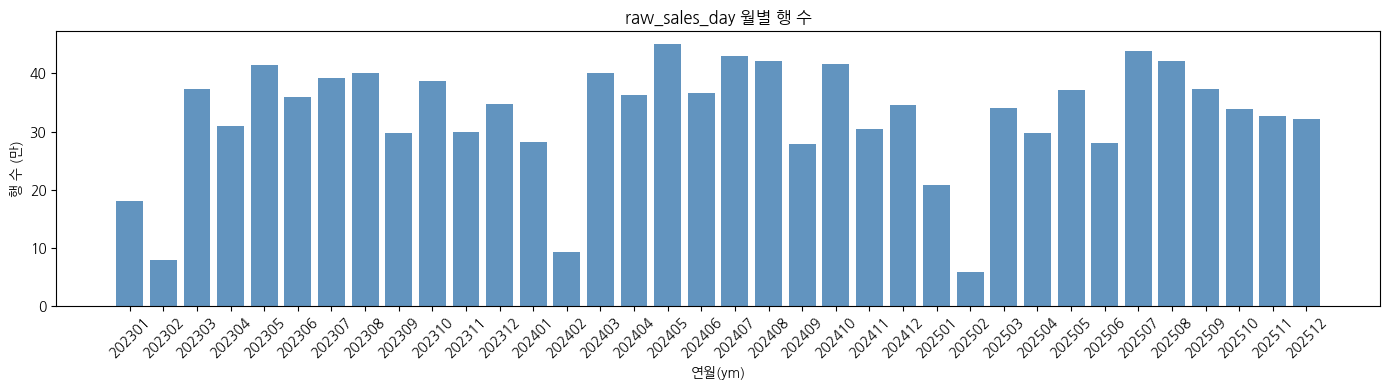

In [21]:
# 전체 파일에서 월별 행 수 확인 (Row Group별 첫 행만 읽음)
pf = pq.ParquetFile(os.path.join(PQ_DIR, 'raw_sales_day.parquet'))
ym_counts = {}
for i in range(pf.metadata.num_row_groups):
    batch = pf.read_row_group(i, columns=['ym']).to_pandas()
    ym = int(batch['ym'].iloc[0])
    ym_counts[ym] = len(batch)

ym_df = pd.DataFrame(ym_counts.items(), columns=['ym','행 수']).sort_values('ym')
ym_df['행 수(만)'] = (ym_df['행 수'] / 10000).round(1)
print('[월별 행 수]')
display(ym_df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(ym_df['ym'].astype(str), ym_df['행 수(만)'], color='steelblue', alpha=0.85)
ax.set_xlabel('연월(ym)')
ax.set_ylabel('행 수 (만)')
ax.set_title('raw_sales_day 월별 행 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


---
## 11. 전체 파일 크기 비교

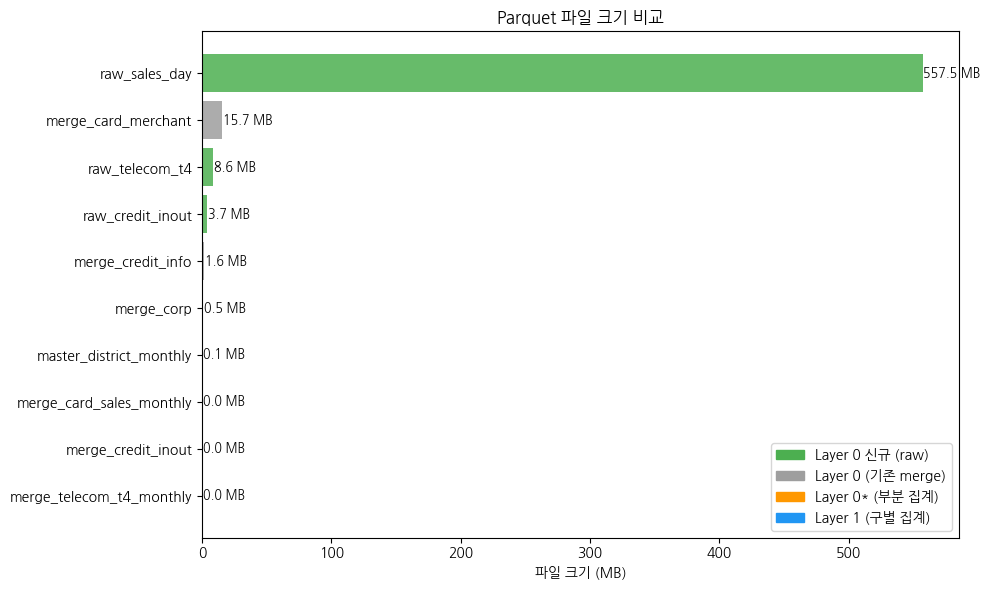

In [22]:
fi_list = []
for f in files:
    size_mb = os.path.getsize(os.path.join(PQ_DIR, f)) / 1024**2
    fi_list.append({'파일': f.replace('.parquet',''), '크기(MB)': size_mb})
fi_df = pd.DataFrame(fi_list).sort_values('크기(MB)', ascending=True)

color_map = {
    'raw_': '#4CAF50',
    'master': '#2196F3',
    '_monthly': '#FF9800',
    'credit_inout': '#FF9800',
}
def get_color(name):
    if name.startswith('raw_'): return '#4CAF50'
    if 'master' in name: return '#2196F3'
    if 'monthly' in name or (name == 'merge_credit_inout'): return '#FF9800'
    return '#9E9E9E'
colors = [get_color(r) for r in fi_df['파일']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df['파일'], fi_df['크기(MB)'], color=colors, alpha=0.85)
ax.set_xlabel('파일 크기 (MB)')
ax.set_title('Parquet 파일 크기 비교')
for bar, val in zip(bars, fi_df['크기(MB)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            '{:.1f} MB'.format(val), va='center', fontsize=9)

from matplotlib.patches import Patch
legend_items = [
    Patch(color='#4CAF50', label='Layer 0 신규 (raw)'),
    Patch(color='#9E9E9E', label='Layer 0 (기존 merge)'),
    Patch(color='#FF9800', label='Layer 0* (부분 집계)'),
    Patch(color='#2196F3', label='Layer 1 (구별 집계)'),
]
ax.legend(handles=legend_items, loc='lower right')
plt.tight_layout()
plt.show()
